### Detección de Movimientos: Paso a Paso

En este notebook vamos a simular lo que hace el bucle principal, pero analizando solo dos momentos exactos: un frame de referencia (tablero quieto) y un frame nuevo (después de mover una pieza). Vamos a calcular la diferencia de energía y usar `python-chess` para adivinar la jugada.

In [20]:
import cv2 as cv
import numpy as np
import chess
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))
from parser_table import ParserTable

def mostrar_imagenes(img1, img2, titulo1="Imagen 1", titulo2="Imagen 2"):
    """Helper para mostrar dos imágenes lado a lado."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(img1, cmap='gray' if len(img1.shape) == 2 else None)
    axs[0].set_title(titulo1)
    axs[0].axis('off')
    axs[1].imshow(img2, cmap='gray' if len(img2.shape) == 2 else None)
    axs[1].set_title(titulo2)
    axs[1].axis('off')
    plt.show()

def get_energia(imagen):
    return np.mean(imagen.astype(np.float32) ** 2)

#### 1. Cargar Frames y el Tablero Lógico
Para esta prueba, vamos a extraer dos frames del video. Inicializamos `ParserTable` con el de referencia y armamos el tablero lógico de `python-chess`.

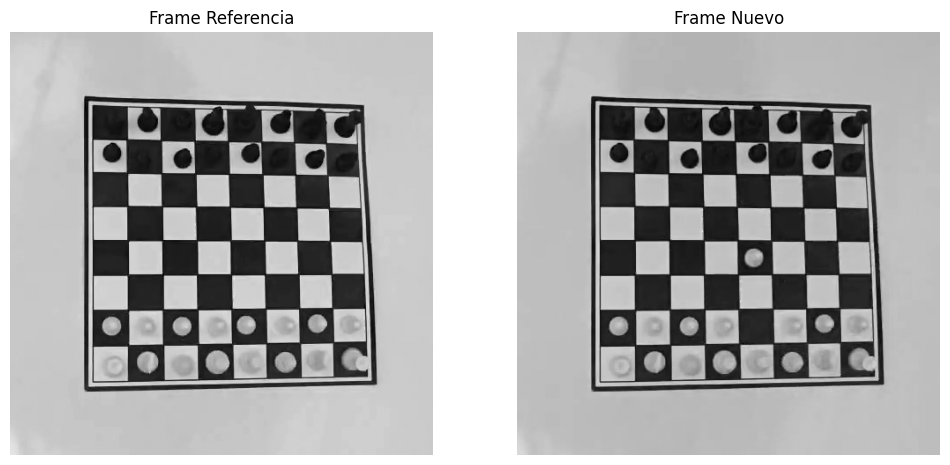

In [21]:
cap = cv.VideoCapture("../../../data/raw/Prueba_Completa.mp4")
cap.set(cv.CAP_PROP_POS_FRAMES, 50)  # Frame antes de mover
ret, frame1 = cap.read()
frame_ref = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)

cap.set(cv.CAP_PROP_POS_FRAMES, 750) # Frame después de mover 
ret, frame2 = cap.read()
frame_nuevo = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)
cap.release()

# Inicializamos el parser y el tablero de ajedrez
LADO = 800
parser = ParserTable(frame_ref)
parser.detect_board_corners()
parser.correct_perspective(LADO)
parser.standardize_orientation()
parser.detect_grid_lines()

board_logico = chess.Board()

mostrar_imagenes(frame_ref, frame_nuevo, "Frame Referencia", "Frame Nuevo")

#### 2. Diferencia de Imagen (Absdiff) y Warp
Restamos los dos frames (`cv.absdiff`). Lo que no se movió se vuelve negro (diferencia cero), y lo que cambió brilla. Luego, le aplicamos la matriz de homografía (`parser.H`) para planchar esa diferencia sobre nuestra grilla perfecta de 800x800.

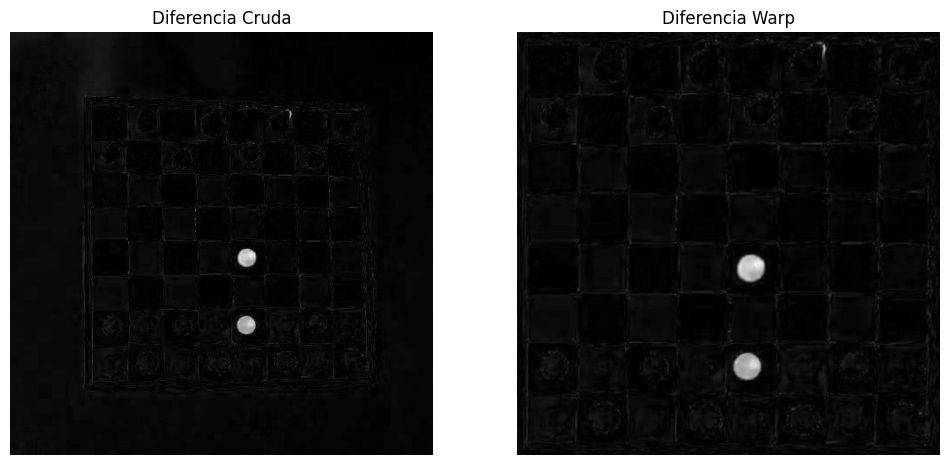

In [22]:
diferencia = cv.absdiff(frame_nuevo, frame_ref)
diferencia_warp = cv.warpPerspective(diferencia, parser.H, (LADO, LADO))

mostrar_imagenes(diferencia, diferencia_warp, "Diferencia Cruda", "Diferencia Warp")

#### 3. Analizar Energía por Celda
Ahora cortamos esa imagen `diferencia_warp` en 64 pedacitos usando las coordenadas del parser (`y_pos` y `x_pos`). Calculamos la "energía" de cada cuadradito. Los que superen el umbral son las casillas donde hubo acción.

In [23]:
y_pos, x_pos = parser.y_pos, parser.x_pos
umbral_pieza = 50

ENERGIAS = np.zeros((8, 8), dtype=np.float32)

# Iteramos las 64 celdas
for i in range(8):
    for j in range(8):
        y1, y2 = y_pos[i], y_pos[i + 1]
        x1, x2 = x_pos[j], x_pos[j + 1]
        recorte = diferencia_warp[y1:y2, x1:x2]
        ENERGIAS[i, j] = get_energia(recorte)

# Buscamos cuáles superaron el umbral y las ordenamos por mayor energía
flat = ENERGIAS.ravel()
validos = np.where(flat > umbral_pieza)[0]

# Agarramos las 6 con más energía (por si se movieron un par de cosas extra)
ordenados = validos[np.argsort(flat[validos])[::-1]][:6]
cambiadas = [(int(idx // 8), int(idx % 8)) for idx in ordenados]

print("Matriz de Energías:")
print(np.round(ENERGIAS, 0))
print(f"\nCeldas detectadas con movimiento (Fila, Col): {cambiadas}")

Matriz de Energías:
[[  21.   56.   19.   55.   31.  141.   28.   45.]
 [  59.   24.   48.   30.   52.   20.   44.   20.]
 [  26.   43.   19.   36.   23.   40.   23.   36.]
 [  48.   19.   56.   23.   40.   15.   32.   20.]
 [  13.   61.   21.   54. 3151.   29.   28.   43.]
 [  63.   18.   54.   18.   36.   27.   45.   32.]
 [  59.   51.   36.   58. 2504.   64.   45.   41.]
 [  70.   47.   54.   52.   48.   56.   51.   62.]]

Celdas detectadas con movimiento (Fila, Col): [(4, 4), (6, 4), (0, 5), (7, 0), (6, 5), (5, 0)]


#### 4. Inferir el Movimiento Lógico
Ya sabemos qué celdas físicas cambiaron. Ahora le preguntamos a `python-chess` de las jugadas legales en este turno, cuál es la que afecta a estas celdas?.

In [24]:
def celda_a_square(fila, col): return chess.square(col, 7 - fila)
def celda_a_uci(fila, col): return "abcdefgh"[col] + str(8 - fila)

def _celdas_afectadas(board, mov):
    antes = {sq: p.symbol() for sq, p in board.piece_map().items()}
    board.push(mov)
    despues = {sq: p.symbol() for sq, p in board.piece_map().items()}
    board.pop()
    
    afectadas = set()
    for sq in set(antes) | set(despues):
        if antes.get(sq) != despues.get(sq):
            afectadas.add((7 - chess.square_rank(sq), chess.square_file(sq)))
    return afectadas

# Lógica de inferencia
turno = board_logico.turn
set_cambiadas = set(cambiadas)

# Buscamos cuáles de las celdas cambiadas tenían una pieza nuestra al principio
origenes = [c for c in cambiadas if board_logico.piece_at(celda_a_square(*c)) and board_logico.piece_at(celda_a_square(*c)).color == turno]

candidatos = []
for (fo, co) in origenes:
    for (fd, cd) in cambiadas:
        if (fd, cd) == (fo, co): continue
        
        base_uci = celda_a_uci(fo, co) + celda_a_uci(fd, cd)
        
        # Probamos movimiento normal y posibles coronaciones (q, r, b, n)
        for sufijo in ("", "q", "r", "b", "n"):
            try:
                mov = chess.Move.from_uci(base_uci + sufijo)
                if mov in board_logico.legal_moves:
                    # ¿Cuántas celdas cambiadas explica este movimiento?
                    explica = len(_celdas_afectadas(board_logico, mov) & set_cambiadas)
                    energia_total = float(ENERGIAS[fo, co] + ENERGIAS[fd, cd])
                    candidatos.append((explica, energia_total, mov))
            except ValueError:
                pass

if candidatos:
    # Ordenamos por la jugada que explica más celdas cambiadas y con mayor energía
    candidatos.sort(key=lambda x: (x[0], x[1]), reverse=True)
    mejor_mov = candidatos[0][2]
    print(f"UCI: {mejor_mov.uci()} (SAN: {board_logico.san(mejor_mov)})")
    
    # Aplicamos al tablero
    board_logico.push(mejor_mov)
    print("Tablero actualizado:")
    print(board_logico)
else:
    print("No se encontró ningún movimiento legal que encaje con estas celdas.")

UCI: e2e4 (SAN: e4)
Tablero actualizado:
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . P . . .
. . . . . . . .
P P P P . P P P
R N B Q K B N R
